# Racetrack — Monte Carlo Control
Bài tập 5.12 (Sutton & Barto) — On-policy, Off-policy WIS/OIS, Per-decision IS

In [4]:
# ── Cell 1: Setup đường dẫn (chạy đầu tiên) ────────────────────
import sys, os

def find_root():
    candidates = [
        os.path.dirname(os.path.abspath('__file__')),
        '/kaggle/working/racetrack_mc',
        '/kaggle/input/racetrack-mc/racetrack_mc',
        os.getcwd(),
    ]
    for path in candidates:
        if os.path.exists(os.path.join(path, 'config.py')):
            return path
    return os.getcwd()

ROOT = find_root()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f'ROOT = {ROOT}')
print(f'Files: {os.listdir(ROOT)}')

ROOT = c:\Users\LENOVO\Downloads\khu lap trinh\project1\racetrack_mc
Files: ['.gitignore', 'config.py', 'experiment.ipynb', 'README.md', 'requirements.txt', 'results', 'src', 'venv', '__pycache__']


In [ ]:
# ── Cell 2: Clone repo (chỉ chạy trên Kaggle nếu chưa có) ──────
# Bỏ qua cell này nếu chạy local hoặc đã upload dataset lên Kaggle

import subprocess

REPO_URL  = 'https://github.com/<your_username>/racetrack_mc.git'
CLONE_DIR = '/kaggle/working/racetrack_mc'

if not os.path.exists(CLONE_DIR):
    subprocess.run(['git', 'clone', REPO_URL, CLONE_DIR], check=True)
    print('Clone xong!')
else:
    print('Repo đã có, bỏ qua clone.')

ROOT = CLONE_DIR
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print(f'ROOT = {ROOT}')

In [6]:
# ── Cell 3: Import modules ──────────────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from config import EPISODES, TRACK_ID, RESULTS_DIR
from src.track  import RaceTrack
from src.agents import OnPolicyAgent, WISAgent, OISAgent, PerDecisionAgent
from src.train  import train, run_demo, compare_agents
from src.plot   import (
    plot_track,
    plot_trajectory,
    plot_learning_curve,
    plot_episode_length_distribution,
    _draw_track,
    AGENT_COLORS,
)

print(f'Results sẽ lưu vào: {RESULTS_DIR}')
print('Import xong!')

Results sẽ lưu vào: c:\Users\LENOVO\Downloads\khu lap trinh\project1\racetrack_mc\results
Import xong!


## 1. Khởi tạo môi trường

Track 1: 34 rows x 19 cols
Start cells : 6 ô
Finish cells: 6 ô


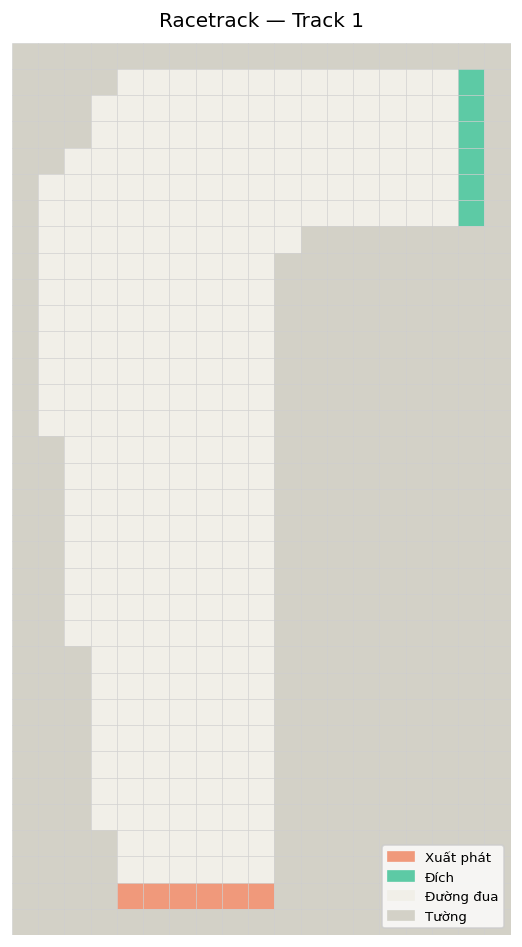

In [7]:
# ── Cell 4: Khởi tạo track & vẽ bản đồ ────────────────────────
track = RaceTrack(track_id=TRACK_ID)

print(f'Track {TRACK_ID}: {track.n_rows} rows x {track.n_cols} cols')
print(f'Start cells : {len(track.start_cells)} ô')
print(f'Finish cells: {len(track.finish_cells)} ô')

plot_track(track, title=f'Racetrack — Track {TRACK_ID}', save=False)

## 2. Train 1 agent (thử nghiệm nhanh)
Bỏ comment agent muốn thử. Đổi `use_noise` để so sánh.

In [8]:
# ── Cell 5: Train 1 agent ───────────────────────────────────────
agent = OnPolicyAgent(epsilon=0.1, gamma=1.0)
# agent = WISAgent(behaviour='random')
# agent = WISAgent(behaviour='epsilon')
# agent = OISAgent(behaviour='random')
# agent = OISAgent(behaviour='epsilon')
# agent = PerDecisionAgent()

result_single = train(
    agent,
    track,
    n_episodes=EPISODES,
    log_every=500,
    use_noise=True,   # True = đúng đề bài, False = không nhiễu
)

[   500/10000] avg length:  412.2 | success rate:  66.0%
[  1000/10000] avg length:   73.0 | success rate: 100.0%
[  1500/10000] avg length:   76.5 | success rate: 100.0%
[  2000/10000] avg length:   68.7 | success rate: 100.0%
[  2500/10000] avg length:   65.2 | success rate:  99.8%
[  3000/10000] avg length:   69.8 | success rate: 100.0%
[  3500/10000] avg length:   67.9 | success rate: 100.0%
[  4000/10000] avg length:   68.0 | success rate: 100.0%
[  4500/10000] avg length:   62.1 | success rate: 100.0%
[  5000/10000] avg length:   62.0 | success rate: 100.0%
[  5500/10000] avg length:   61.6 | success rate: 100.0%
[  6000/10000] avg length:   62.4 | success rate: 100.0%
[  6500/10000] avg length:   62.2 | success rate: 100.0%
[  7000/10000] avg length:   61.3 | success rate: 100.0%
[  7500/10000] avg length:   64.6 | success rate: 100.0%
[  8000/10000] avg length:   60.5 | success rate: 100.0%
[  8500/10000] avg length:   59.9 | success rate: 100.0%
[  9000/10000] avg length:   64

## 3. So sánh có noise vs không noise (cùng 1 agent)

In [10]:
# ── Cell 6: Train cùng agent, 1 lần có noise, 1 lần không ──────
agent_noise    = OnPolicyAgent(epsilon=0.1, gamma=1.0)
agent_no_noise = OnPolicyAgent(epsilon=0.1, gamma=1.0)

print('--- Training WITH noise ---')
result_noise = train(
    agent_noise, track,
    n_episodes=EPISODES, log_every=500,
    use_noise=True,
)

print('\n--- Training WITHOUT noise ---')
result_no_noise = train(
    agent_no_noise, track,
    n_episodes=EPISODES, log_every=500,
    use_noise=False,
)

--- Training WITH noise ---
[   500/10000] avg length:  483.8 | success rate:  58.4%
[  1000/10000] avg length:  132.1 | success rate:  97.6%
[  1500/10000] avg length:  109.7 | success rate:  99.4%
[  2000/10000] avg length:   98.1 | success rate:  99.2%
[  2500/10000] avg length:   69.1 | success rate: 100.0%
[  3000/10000] avg length:   70.7 | success rate: 100.0%
[  3500/10000] avg length:   67.7 | success rate: 100.0%
[  4000/10000] avg length:   76.3 | success rate: 100.0%
[  4500/10000] avg length:   75.2 | success rate: 100.0%
[  5000/10000] avg length:   70.1 | success rate:  99.8%
[  5500/10000] avg length:   73.3 | success rate: 100.0%
[  6000/10000] avg length:   69.5 | success rate: 100.0%
[  6500/10000] avg length:   68.0 | success rate: 100.0%
[  7000/10000] avg length:   69.2 | success rate: 100.0%
[  7500/10000] avg length:   68.3 | success rate: 100.0%
[  8000/10000] avg length:   68.9 | success rate: 100.0%
[  8500/10000] avg length:   74.8 | success rate: 100.0%
[  

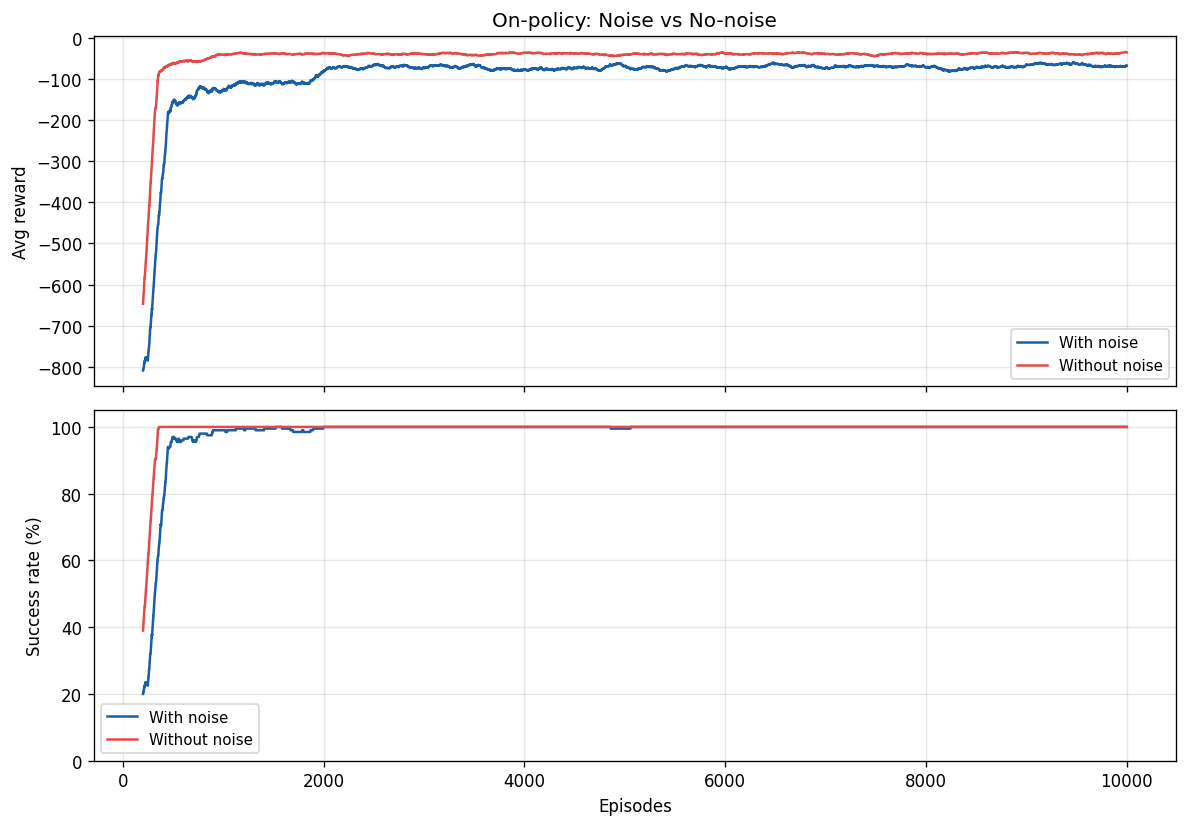

In [11]:
# ── Cell 7: Vẽ so sánh noise vs no-noise ───────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
window = 200

for label, data, color in [
    ('With noise',    result_noise,    '#185FA5'),
    ('Without noise', result_no_noise, '#E24B4A'),
]:
    rewards = data['rewards']
    lengths = data['episode_lengths']
    ma_r = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ma_s = np.convolve(
        [1 if l < 500 else 0 for l in lengths],
        np.ones(window)/window, mode='valid'
    )
    x = np.arange(window, len(rewards) + 1)
    ax1.plot(x, ma_r,       label=label, color=color, linewidth=1.5)
    ax2.plot(x, ma_s * 100, label=label, color=color, linewidth=1.5)

ax1.set_ylabel('Avg reward', fontsize=10)
ax1.set_title('On-policy: Noise vs No-noise', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Episodes', fontsize=10)
ax2.set_ylabel('Success rate (%)', fontsize=10)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. So sánh tất cả agents

In [12]:
# ── Cell 8: Train tất cả agents — có noise (đúng đề bài) ───────
print('=== Training WITH noise ===')
results_noise = compare_agents(track, n_episodes=EPISODES, use_noise=True)

=== Training WITH noise ===

Training: On-policy  |  noise=ON
[   500/10000] avg length:  280.7 | success rate:  77.4%
[  1000/10000] avg length:   69.1 | success rate: 100.0%
[  1500/10000] avg length:   62.2 | success rate: 100.0%
[  2000/10000] avg length:   54.3 | success rate: 100.0%
[  2500/10000] avg length:   56.6 | success rate: 100.0%
[  3000/10000] avg length:   55.2 | success rate: 100.0%
[  3500/10000] avg length:   55.4 | success rate: 100.0%
[  4000/10000] avg length:   57.6 | success rate: 100.0%
[  4500/10000] avg length:   60.7 | success rate: 100.0%
[  5000/10000] avg length:   55.8 | success rate: 100.0%
[  5500/10000] avg length:   57.0 | success rate: 100.0%
[  6000/10000] avg length:   56.7 | success rate: 100.0%
[  6500/10000] avg length:   55.0 | success rate: 100.0%
[  7000/10000] avg length:   54.3 | success rate: 100.0%
[  7500/10000] avg length:   53.9 | success rate: 100.0%
[  8000/10000] avg length:   52.7 | success rate: 100.0%
[  8500/10000] avg length:

KeyboardInterrupt: 

In [ ]:
# ── Cell 9: Train tất cả agents — không noise (để so sánh) ─────
print('=== Training WITHOUT noise ===')
results_no_noise = compare_agents(track, n_episodes=EPISODES, use_noise=False)

## 5. Visualize kết quả

In [ ]:
# ── Cell 10: Learning curve — có noise ─────────────────────────
plot_learning_curve(results_noise,    window=200, save=False)

In [ ]:
# ── Cell 11: Learning curve — không noise ──────────────────────
plot_learning_curve(results_no_noise, window=200, save=False)

In [ ]:
# ── Cell 12: Phân phối độ dài episode ──────────────────────────
print('--- With noise ---')
plot_episode_length_distribution(results_noise,    save=False)

print('--- Without noise ---')
plot_episode_length_distribution(results_no_noise, save=False)

## 6. Demo trajectory theo policy tối ưu (noise OFF)

In [ ]:
# ── Cell 13: Demo 1 agent ───────────────────────────────────────
# Chọn agent từ results_noise hoặc results_no_noise
demo_agent = results_noise['On-policy']['agent']
# demo_agent = results_noise['WIS (epsilon)']['agent']
# demo_agent = results_no_noise['On-policy']['agent']

print('Chạy demo trajectory (noise OFF)...')
demos = run_demo(demo_agent, track, n_demos=5)

plot_trajectory(
    track,
    demos,
    title='Trajectory theo greedy policy (noise OFF)',
    save=False,
)

In [ ]:
# ── Cell 14: So sánh trajectory tất cả agents ──────────────────
# Đổi results_noise <-> results_no_noise để so sánh
results_to_demo = results_noise

fig, axes = plt.subplots(2, 3, figsize=(14, 18))

for ax, (name, data) in zip(axes.flatten(), results_to_demo.items()):
    _draw_track(ax, track)
    traj  = run_demo(data['agent'], track, n_demos=1)[0]
    color = AGENT_COLORS.get(name, '#333')
    cols  = [s[1] + 0.5 for s in traj]
    rows  = [track.n_rows - s[0] - 0.5 for s in traj]
    ax.plot(cols, rows, '-o', color=color, linewidth=1.5, markersize=3)
    ax.plot(cols[0], rows[0], 's', color=color, markersize=8, label='Start')
    ax.legend(fontsize=8)
    ax.set_title(f'{name} ({len(traj)} bước)', fontsize=10)

fig.suptitle('So sánh trajectory — tất cả agents (noise OFF)', fontsize=13)
plt.tight_layout()
plt.show()